In [2]:
import pandas as pd

#read the data from dataset
#从数据集中读取数据
file_path = r'C:\Users\yuentolong\Dataset .csv'
data = pd.read_csv(file_path,encoding = 'latin-1')


In [3]:
#Calculate the percentage of restaurants offering online delivery
#计算提供网上派送的餐厅的百分比
restaurants_counts = len(data)

#count the restaurants offering online delivery
#数出提供线上派送的餐厅

#  Method 1 法1
#        restaurants_offerOnlineDelivery_counts = data[ data['Has Online delivery'] == 'Yes' ].shape[0]
#        restaurants_offerOnlineDelivery_counts
#        percentage_OfferOnlineDelivery = round((restaurants_offerOnlineDelivery_counts / restaurants_counts) * 100,3) 
#       #Attention : Can't use '.round()' because 'round' is not a float method 
#       #注意：不能使用.round()因为round不是float方法
 

#  Method 2 法2
restaurants_offerOnlineDelivery_counts = ( data['Has Online delivery'] == 'Yes').sum()
percentage_OfferOnlineDelivery = ((restaurants_offerOnlineDelivery_counts / restaurants_counts) * 100).round(3)
print(f'The percentage of the restaurants offering online delivery / 提供线上派送餐厅百分比:{percentage_OfferOnlineDelivery: .2f}%')

The percentage of the restaurants offering online delivery / 提供线上派送餐厅百分比: 25.66%


In [4]:
#Compare average rating between restaurants with and without online delivery
#比较使用线上派送和不使用线上派送的平均评分
restaurants_offerOnlineDelivery_rating = data.loc[data['Has Online delivery'] == 'Yes']['Aggregate rating'].mean()
restaurants_donot_offerOnlineDelivery_rating = data.loc[data['Has Online delivery'] == 'No']['Aggregate rating'].mean()
print(f'Average rating of restaurants with online delivery / 提供线上派送的餐厅的平均评分:{restaurants_offerOnlineDelivery_rating:.2f}%')
print(f'Average rating of restaurants wihout online delivery / 不提供线上派送的餐厅平均评分:{restaurants_donot_offerOnlineDelivery_rating:.2f}%')

#print the result
#输出结果
if restaurants_offerOnlineDelivery_rating > restaurants_donot_offerOnlineDelivery_rating:
    print('Result:The restaurants offering online delivery will get higher average rating / 结论：提供线上派送的餐厅平均评分更高')
elif restaurants_offerOnlineDelivery_rating < restaurants_donot_offerOnlineDelivery_rating:
    print('Result:The restaurants without online delivery will get higher average rating / 结论：不提供线上派送的餐厅平均评分更高')
else :
    print('Result:No matter offer online delivery or not,there is no difference between them / 结论：不论提供与否，他们都没有区别')


Average rating of restaurants with online delivery / 提供线上派送的餐厅的平均评分:3.25%
Average rating of restaurants wihout online delivery / 不提供线上派送的餐厅平均评分:2.47%
Result:The restaurants offering online delivery will get higher average rating / 结论：提供线上派送的餐厅平均评分更高


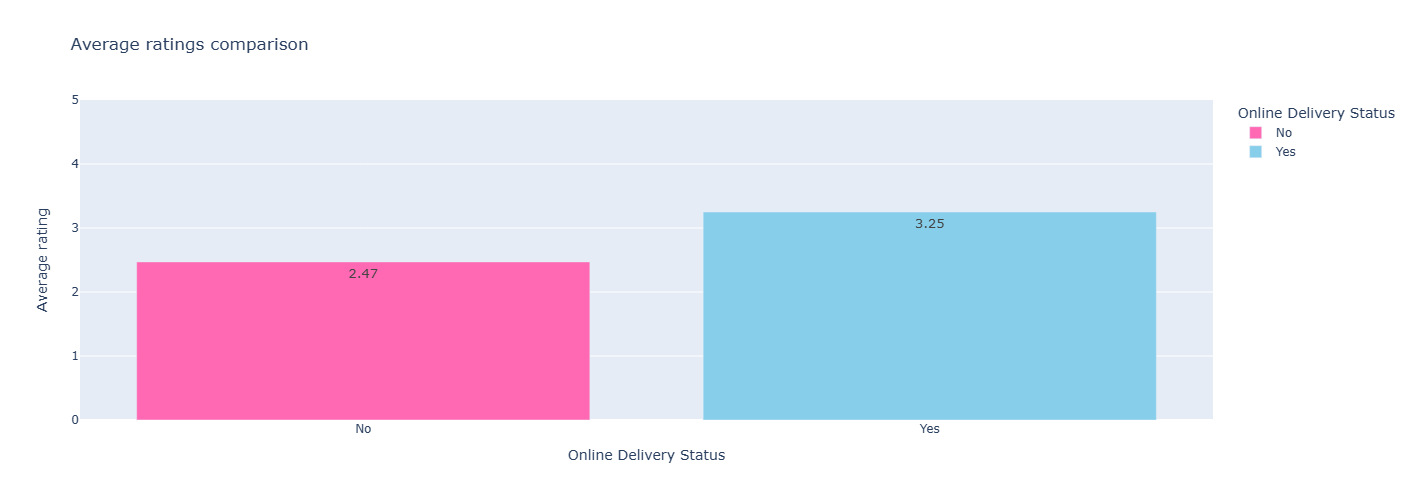

In [17]:
#Visualization of result
#结果可视化
import plotly.express as px

dataGroup = data[['Has Online delivery','Aggregate rating']].groupby('Has Online delivery')
total_rating = dataGroup.mean().round(2)
#Attention: We can't use total_rating making a dataframe to generate a plot cause the shape of 'total_rating' is Series or dataframe,but plotly expects a structured dataframe
#注意：我们不能使用total_rating来做dataframe，因为它是‘series’或者‘dataframe’类型，而plotly绘图需要干净的dataframe类型

df_plot = total_rating.reset_index()
df_plot.columns = ['Online Delivery Status', 'Average rating']

fig = px.bar(
    df_plot,
    x = 'Online Delivery Status',
    y = 'Average rating',
    title = 'Average ratings comparison',

    #method 1 Use '.map({...}.format)' 法1,使用.map({...}.format)
    # text = df_plot['Average rating'].map('{:.2f}'.format),

    #method 2 Use '.round().astype()' 法2,使用.round().astype()
    text = df_plot['Average rating'].round(2).astype(str),
    
    color = 'Online Delivery Status',
    color_discrete_sequence = ['hotpink','skyblue']
    # color = 'Average rating',
    # color_continuous_scale = 'Viridis'
    #Here is only two objects,so there is no need for viridis
    #这里只有两个对象，所以没有必要使用渐变色
)

fig.update_traces(textposition = 'auto',textfont_size = 13)
fig.update_layout(
                 xaxis_type = 'category',
                 yaxis_title = 'Average rating',
                 yaxis = dict(range = [0,5]),
                 height = 500,
                 width = 600
)

fig.show()

